<a href="https://colab.research.google.com/github/javed005/C5-Project_-Financial-Risk-Analysis-with-Python/blob/main/C5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Date handling
from datetime import timedelta

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [4]:
# Upload CSV manually in Colab or use drive path
df = pd.read_csv('/content/Barclays Financial Transactional Data - barclays.csv')

# Preview data
df.head()


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,118,CUST3810,ACC49774,Savings,Deposit,Credit Card,Firm D,West,Manager 4,08-01-2024,20664.409820,88483.42208,0.483333,522,29
1,102,CUST3109,ACC96277,Savings,Deposit,Mutual Fund,Firm B,North,Manager 4,17-12-2023,94924.359120,56670.15864,0.788989,686,130
2,151,CUST2626,ACC21429,Credit,Payment,Personal Loan,Firm C,West,Manager 1,22-05-2024,-7871.160407,84968.05587,0.547782,618,157
3,57,CUST3725,ACC48501,Loan,Withdrawal,Credit Card,Firm A,East,Manager 4,24-12-2023,24979.808160,115196.96420,0.125587,803,155
4,113,CUST4258,ACC11285,Loan,Transfer,Home Loan,Firm A,West,Manager 4,15-01-2023,72890.748550,111602.76610,1.048787,657,68


TASK 1

In [5]:
# Remove currency symbols, commas
df['TransactionAmount'] = (
    df['TransactionAmount']
    .astype(str)
    .str.replace('[₹$,]', '', regex=True)
    .astype(float)
)

df['AccountBalance'] = (
    df['AccountBalance']
    .astype(str)
    .str.replace('[₹$,]', '', regex=True)
    .astype(float)
)


In [6]:
df.isnull().sum()

df.fillna({
    'RiskScore': df['RiskScore'].median(),
    'CreditRating': df['CreditRating'].median()
}, inplace=True)


In [7]:
df['TransactionDate'] = pd.to_datetime(
    df['TransactionDate'],
    dayfirst=True,
    errors='coerce'
)


In [8]:
df['AccountType'] = df['AccountType'].str.lower().str.strip()
df['TransactionType'] = df['TransactionType'].str.lower().str.strip()


TASK 2

In [9]:
df['Year'] = df['TransactionDate'].dt.year
df['Month'] = df['TransactionDate'].dt.to_period('M')

monthly_summary = df.groupby(['Month', 'TransactionType'])['TransactionAmount'].sum().unstack().fillna(0)
monthly_summary['Net'] = monthly_summary.get('credit', 0) - monthly_summary.get('debit', 0)

monthly_summary.head()


TransactionType,deposit,payment,transfer,withdrawal,Net
Month,,,,,
2023-01,569469.355020,565962.823040,982544.390280,668336.92357,0
2023-02,521830.583465,664746.835860,527550.173090,817252.47485,0
2023-03,342372.905660,384349.988340,391669.732642,383576.63169,0
2023-04,146580.612610,388737.603250,718964.116920,443903.95549,0
2023-05,568697.316343,705533.698249,924744.536970,938412.27445,0


In [10]:
df['TransactionType'].value_counts()


,count
TransactionType,
withdrawal,210
transfer,206
payment,198
deposit,186


In [11]:
df['TransactionType'] = df['TransactionType'].str.lower().str.strip()

df['TransactionType'] = df['TransactionType'].replace({
    'deposit': 'credit',
    'withdrawal': 'debit',
    'payment': 'debit',
    'transfer': 'debit'
})


In [12]:
df['Month'] = df['TransactionDate'].dt.to_period('M')

monthly_summary = (
    df.groupby(['Month', 'TransactionType'])['TransactionAmount']
    .sum()
    .unstack()
    .fillna(0)
)

monthly_summary.head()


TransactionType,credit,debit
Month,,
2023-01,569469.355020,2.216844e+06
2023-02,521830.583465,2.009549e+06
2023-03,342372.905660,1.159596e+06
2023-04,146580.612610,1.551606e+06
2023-05,568697.316343,2.568691e+06


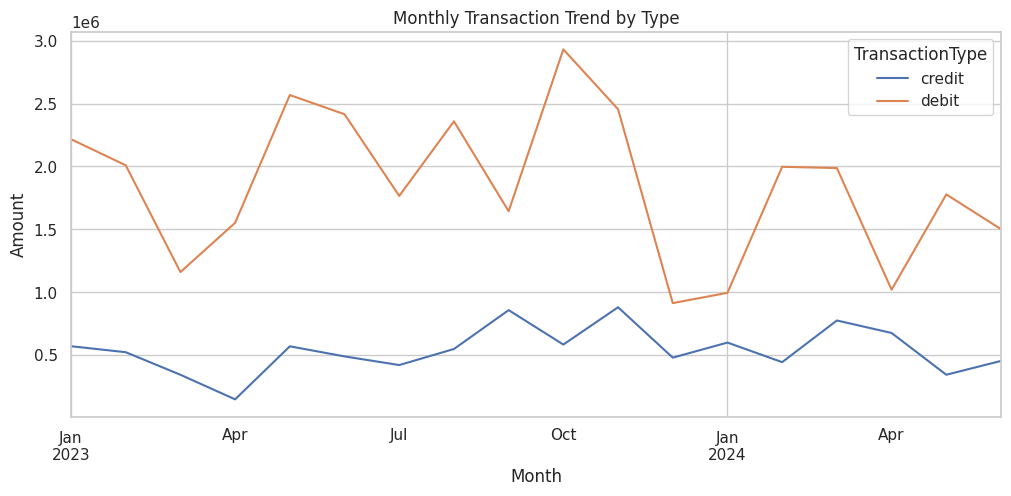

In [13]:
monthly_summary.plot(figsize=(12,5))
plt.title('Monthly Transaction Trend by Type')
plt.ylabel('Amount')
plt.xlabel('Month')
plt.show()


In [14]:
account_net = df.groupby('AccountID')['TransactionAmount'].sum().sort_values(ascending=False)

top_accounts = account_net.head(10)
bottom_accounts = account_net.tail(10)

top_accounts, bottom_accounts


(AccountID
 ACC54589    720103.595590
 ACC92558    645089.102250
 ACC49422    564943.533450
 ACC80131    556260.453470
 ACC42710    552578.283770
 ACC19178    538885.526270
 ACC83581    507631.685320
 ACC94203    493355.012822
 ACC77773    476188.652680
 ACC32890    450092.904840
 Name: TransactionAmount, dtype: float64,
 AccountID
 ACC94907    34686.348400
 ACC22036    34620.171763
 ACC51200    30767.906220
 ACC18177    28894.675830
 ACC89098    27471.750760
 ACC51971    27219.074646
 ACC15671    25166.389040
 ACC52650    19904.777256
 ACC32212     1592.907285
 ACC28154    -2920.562029
 Name: TransactionAmount, dtype: float64)

In [15]:
df_sorted = df.sort_values(['AccountID', 'TransactionDate'])

df_sorted['PrevDate'] = df_sorted.groupby('AccountID')['TransactionDate'].shift(1)
df_sorted['GapDays'] = (df_sorted['TransactionDate'] - df_sorted['PrevDate']).dt.days

dormant_accounts = df_sorted[df_sorted['GapDays'] >= 60]['AccountID'].unique()

len(dormant_accounts)


166

Task 4

In [16]:
txn_freq = df.groupby('AccountID').size()

activity_level = pd.cut(
    txn_freq,
    bins=[0, 5, 20, np.inf],
    labels=['Low', 'Medium', 'High']
)

df_activity = pd.DataFrame({
    'TransactionCount': txn_freq,
    'ActivityLevel': activity_level
})

df_activity.head()


,TransactionCount,ActivityLevel
AccountID,,
ACC10117,4,Low
ACC10996,5,Low
ACC11062,2,Low
ACC11188,4,Low
ACC11285,3,Low


In [17]:
profile = df.groupby('AccountID').agg({
    'TransactionAmount': 'sum',
    'AccountBalance': 'mean'
}).rename(columns={
    'TransactionAmount': 'TotalVolume',
    'AccountBalance': 'AvgBalance'
})

profile.head()


,TotalVolume,AvgBalance
AccountID,,
ACC10117,238427.20992,97828.704775
ACC10996,269471.35221,56982.152538
ACC11062,110594.78398,65947.316965
ACC11188,225517.45894,81169.114065
ACC11285,236119.54601,62574.613950


In [18]:
high_net_inflow = profile[profile['TotalVolume'] > profile['TotalVolume'].quantile(0.75)]

high_freq_low_balance = profile[
    (profile['AvgBalance'] < profile['AvgBalance'].quantile(0.25))
]

negative_balance = profile[profile['AvgBalance'] <= 0]


TASK 4

In [19]:
large_withdrawals = df[
    (df['TransactionType'] == 'debit') &
    (df['TransactionAmount'] > df['TransactionAmount'].quantile(0.95))
]


In [20]:
balance_volatility = df.groupby('AccountID')['AccountBalance'].std()
balance_cv = balance_volatility / df.groupby('AccountID')['AccountBalance'].mean()


In [21]:
df['z_score'] = np.abs(stats.zscore(df['TransactionAmount']))
anomalies = df[df['z_score'] > 3]


TASK 5

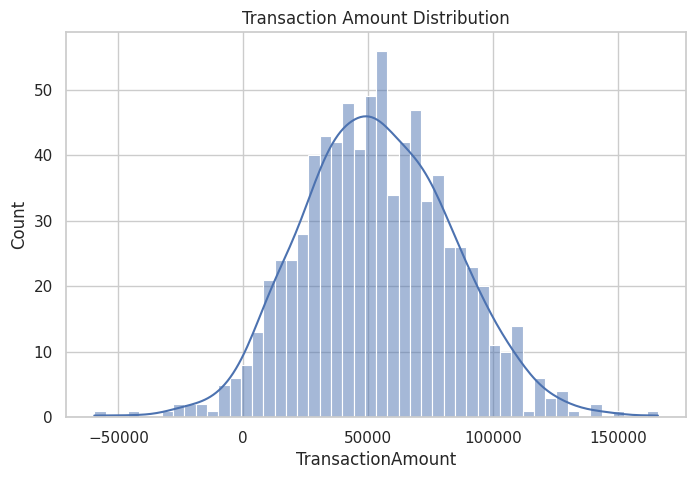

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['TransactionAmount'], bins=50, kde=True)
plt.title('Transaction Amount Distribution')
plt.show()


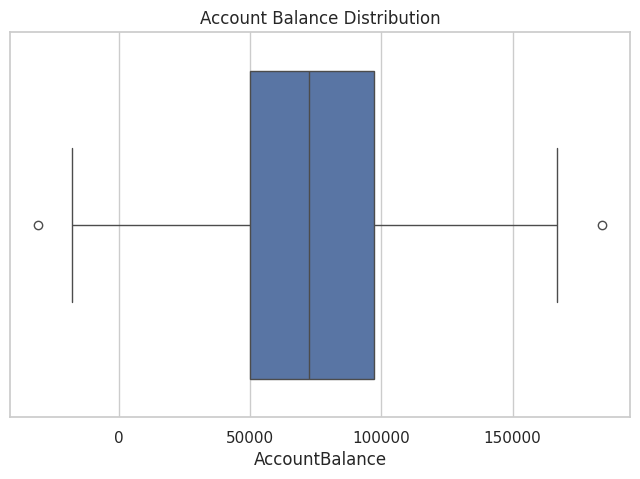

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['AccountBalance'])
plt.title('Account Balance Distribution')
plt.show()


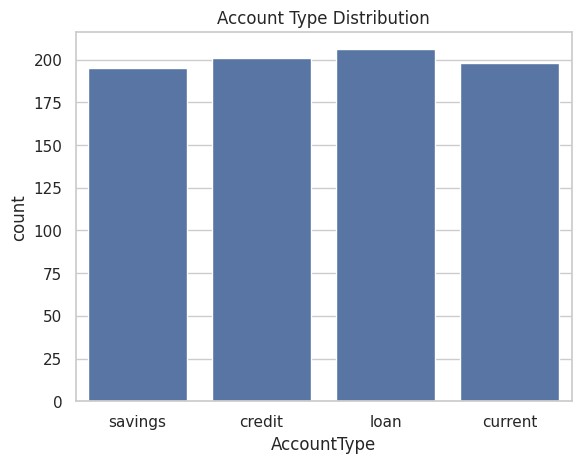

In [24]:
sns.countplot(x='AccountType', data=df)
plt.title('Account Type Distribution')
plt.show()


TASK 6

In [25]:
threshold = profile['TotalVolume'].median()

high_volume = profile[profile['TotalVolume'] >= threshold]['AvgBalance']
low_volume = profile[profile['TotalVolume'] < threshold]['AvgBalance']


In [26]:
t_stat, p_value = stats.ttest_ind(high_volume, low_volume, equal_var=False)

t_stat, p_value


(np.float64(0.5513867514206973), np.float64(0.5820631377349124))

In [27]:
if p_value < 0.05:
    print("Reject H0: High-volume accounts have significantly higher balances")
else:
    print("Fail to reject H0: No significant difference")


Fail to reject H0: No significant difference
